In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import (cross_validate, train_test_split, 
                                     KFold, RandomizedSearchCV, GridSearchCV)
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from xgboost.sklearn import XGBRegressor

In [4]:
df=pd.read_csv("/kaggle/input/datasets/manyaar/insuraance/insurance.csv")

df['smoker_bmi'] = (df['smoker'] == 'yes').astype(int) * df['bmi']
df['smoker_age'] = (df['smoker'] == 'yes').astype(int) * df['age']  

df.head()

,age,sex,bmi,children,smoker,region,charges,smoker_bmi,smoker_age
0,19,female,27.900,0,yes,southwest,16884.92400,27.9,19
1,18,male,33.770,1,no,southeast,1725.55230,0.0,0
2,28,male,33.000,3,no,southeast,4449.46200,0.0,0
3,33,male,22.705,0,no,northwest,21984.47061,0.0,0
4,32,male,28.880,0,no,northwest,3866.85520,0.0,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [15]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [16]:
labelled_data = df.copy()

lb = LabelEncoder()

for col in labelled_data.columns:
    
    if labelled_data[col].dtype == 'object':
        labelled_data[col] = lb.fit_transform(labelled_data[col])

labelled_data.corr(method = 'spearman',numeric_only = True)

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.020809,0.107736,0.056992,-0.025210,0.004315,0.534392
sex,-0.020809,1.000000,0.044802,0.015589,0.076185,0.004614,0.009490
bmi,0.107736,0.044802,1.000000,0.015607,0.002203,0.152959,0.119396
children,0.056992,0.015589,0.015607,1.000000,0.016583,0.010604,0.133339
smoker,-0.025210,0.076185,0.002203,0.016583,1.000000,-0.002155,0.663460
region,0.004315,0.004614,0.152959,0.010604,-0.002155,1.000000,-0.043531
charges,0.534392,0.009490,0.119396,0.133339,0.663460,-0.043531,1.000000


# **EDA : Explorartory Data Analysis**

Text(0.5, 1.0, 'Distribution of charges by age and sex')

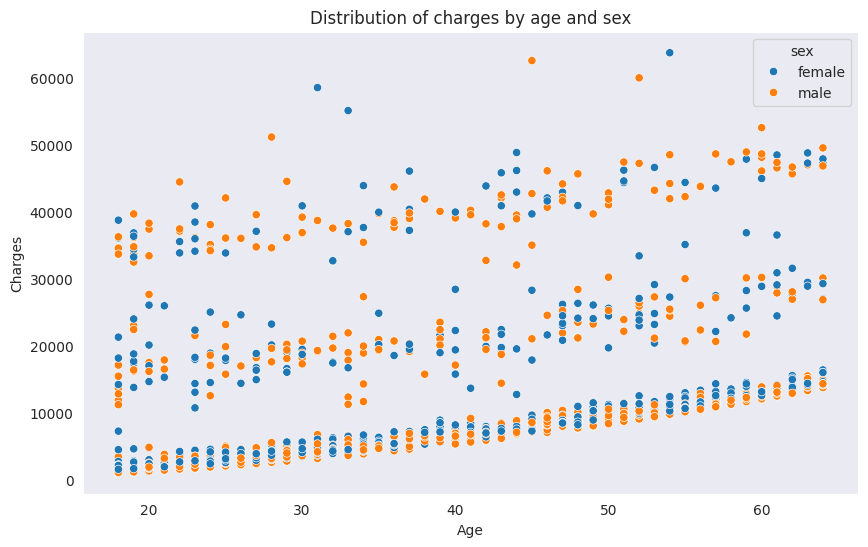

In [17]:
sns.set_style("dark")
plt.figure(figsize = (10,6))

sns.scatterplot(x=df['age'], y=df['charges'], hue=df['sex'],data=df)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Distribution of charges by age and sex")

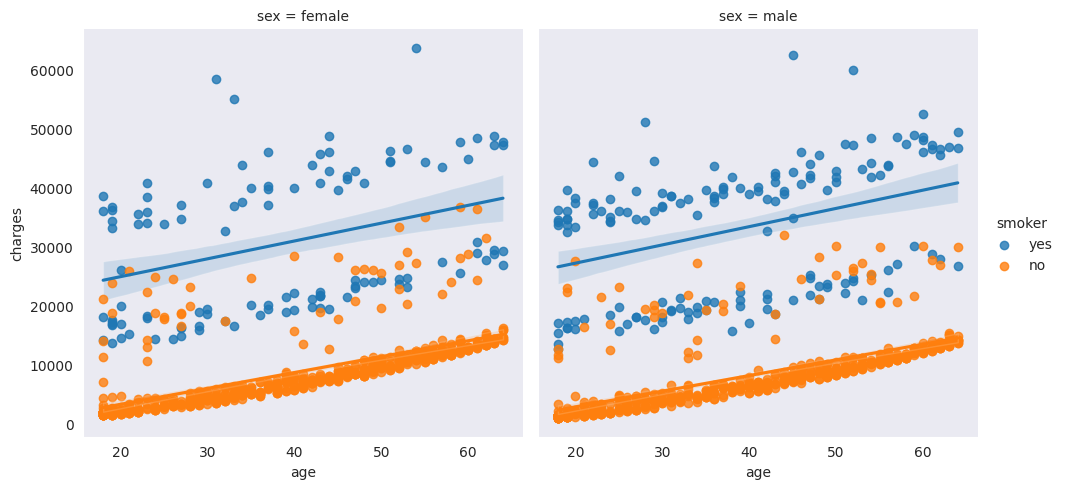

In [18]:
sns.lmplot(data=df, x="age", y="charges", hue="smoker",col="sex",height=5)

<Axes: xlabel='region', ylabel='charges'>

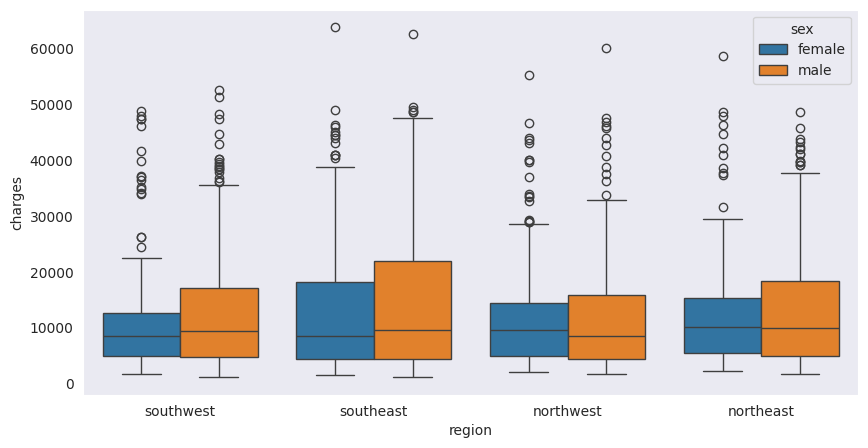

In [19]:
#Boxplot to analyse charges by region and sex

plt.figure(figsize=(10,5))
sns.boxplot(x='region', y='charges', hue='sex', data=df)

Text(0.5, 1.0, 'Distribution of charges by number of children')

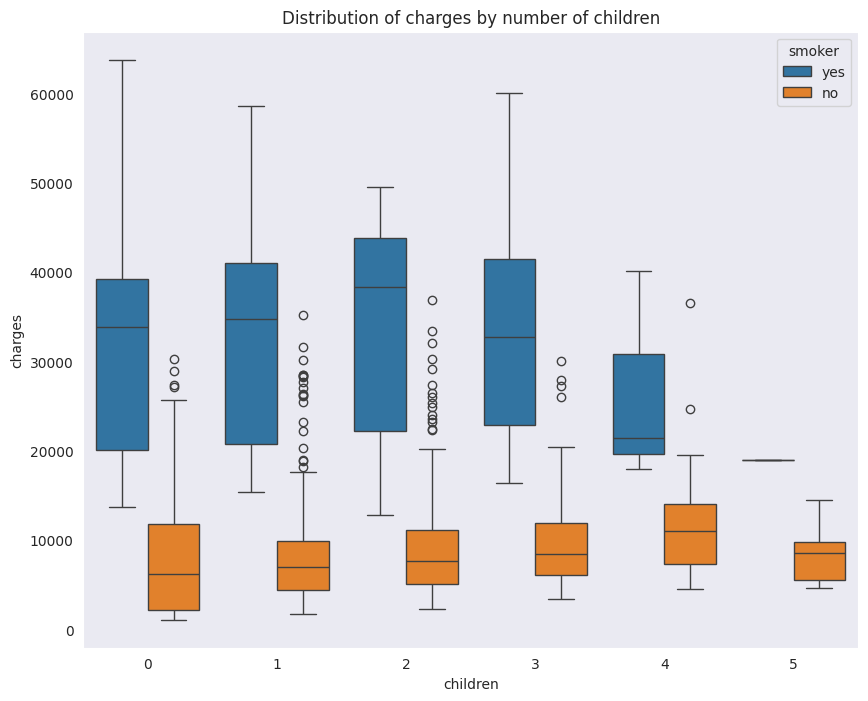

In [20]:
plt.figure(figsize = (10,8))
sns.boxplot(x = "children", y = "charges",hue = "smoker", data =df)
plt.title("Distribution of charges by number of children")

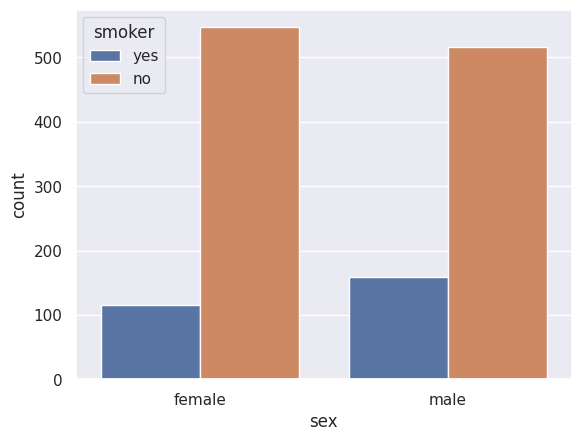

In [21]:
sns.set_theme(style="darkgrid")
ax = sns.countplot(x="sex",hue="smoker",data=df)

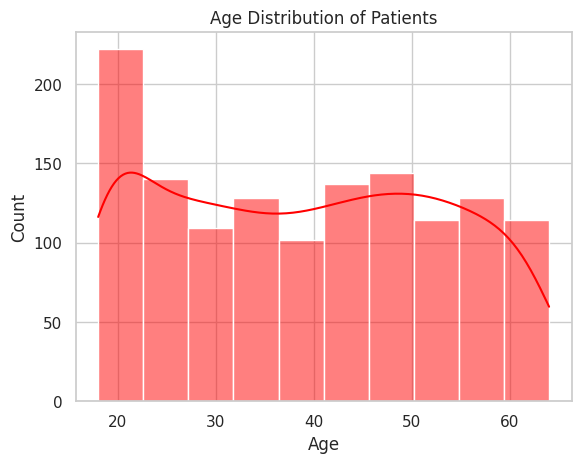

In [25]:

sns.set_style('whitegrid')

#plot of histogram for age

sns.histplot(data=df['age'], kde=True, color='red', bins=10)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.show()

# **Preprocessing**

In [5]:
X = df.drop(['charges'], axis = 1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,random_state = 42)


## Pipeline

In [6]:

preprocess = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['age', 'bmi', 'children', 'smoker_bmi', 'smoker_age']), 
        ('target_enc', TargetEncoder(), ['region']),
        ('one_enc', OneHotEncoder(), ['smoker', 'sex'])
    ],
    remainder = 'drop'
)    

insurancePipeline = Pipeline([
    ('prep', preprocess),
    ('reg', LinearRegression())
])


In [7]:
regs = []
regs.append(RandomForestRegressor(random_state=42))
regs.append(DecisionTreeRegressor(random_state=42))
regs.append(GradientBoostingRegressor(random_state=42))
regs.append(XGBRegressor(random_state=42))

In [8]:
mae_scores = []
scoring = ['neg_mean_absolute_error']
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('\n-------------------------------------- Observations ---------------------------------------\n')
for r in regs:
    insurancePipeline.set_params(reg = r)
    scores = cross_validate(insurancePipeline, X_train, y_train,cv = kf, scoring = scoring)
    mae = -scores['test_neg_mean_absolute_error'].mean()
    mae_scores.append(mae)
    print('\n-----------------------------------')
    print(type(r).__name__)
    print('-----------------------------------')
    for key, values in scores.items():
            print(key,'mean:', f"{values.mean():.5f}")


-------------------------------------- Observations ---------------------------------------


-----------------------------------
RandomForestRegressor
-----------------------------------
fit_time mean: 0.39079
score_time mean: 0.01760
test_neg_mean_absolute_error mean: -2702.41802

-----------------------------------
DecisionTreeRegressor
-----------------------------------
fit_time mean: 0.01467
score_time mean: 0.00549
test_neg_mean_absolute_error mean: -3162.44916

-----------------------------------
GradientBoostingRegressor
-----------------------------------
fit_time mean: 0.15613
score_time mean: 0.00605
test_neg_mean_absolute_error mean: -2683.44867

-----------------------------------
XGBRegressor
-----------------------------------
fit_time mean: 0.18466
score_time mean: 0.00759
test_neg_mean_absolute_error mean: -3257.37289


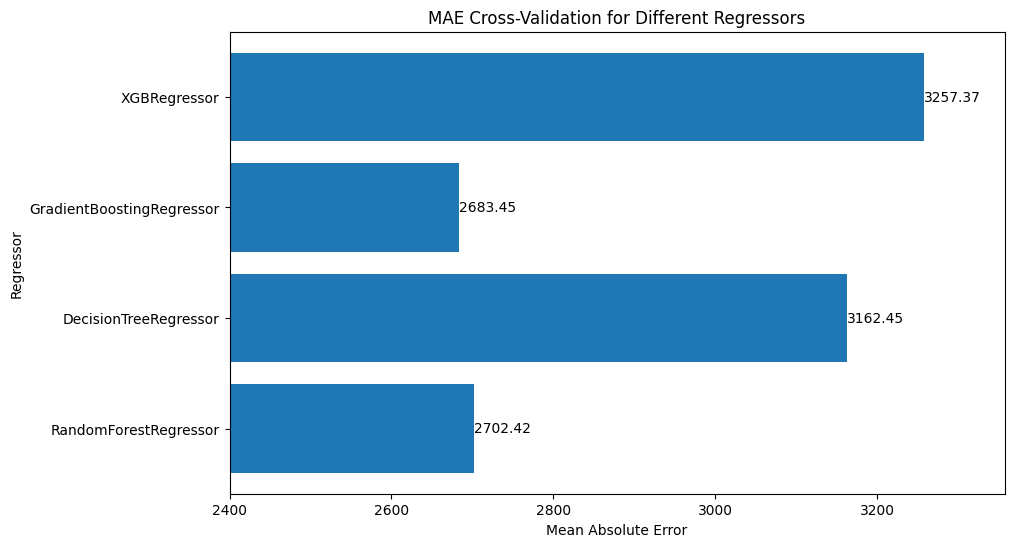

In [9]:
plt.figure(figsize=(10, 6))
bars = plt.barh([type(classifier).__name__ for classifier in regs], mae_scores)
plt.xlabel('Mean Absolute Error')
plt.ylabel('Regressor')
plt.title('MAE Cross-Validation for Different Regressors')
plt.xlim(2400, max(mae_scores) + 100) 

for bar, score in zip(bars, mae_scores):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{score:.2f}',
             va='center', ha='left', fontsize=10, color='black')

plt.show()

## HyperParameter Tuning

In [10]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

print('========= Randomized Search =========\n')

random_param_grids = {
    'RandomForestRegressor': {
        'reg__n_estimators': [50, 100, 150],
        'reg__max_depth': [None, 10, 20],
        'reg__min_samples_split': [2, 5, 10],
        'reg__max_features': ['sqrt', 'log2']
    },
    'GradientBoostingRegressor': {
        'reg__n_estimators': [50, 100, 150],
        'reg__learning_rate': [0.05, 0.1, 0.2],
        'reg__max_depth': [3, 4, 5],
        'reg__subsample': [0.8, 0.9, 1.0]
    },
    'DecisionTreeRegressor': {
        'reg__max_depth': [None, 5, 10],
        'reg__min_samples_split': [2, 5, 10]
    },
    'XGBRegressor': {
        'reg__n_estimators': [50, 100, 150],
        'reg__learning_rate': [0.05, 0.1, 0.2],
        'reg__max_depth': [3, 4, 5],
        'reg__subsample': [0.8, 0.9, 1.0],
        'reg__colsample_bytree': [0.7, 0.8, 1.0],
        'reg__reg_alpha': [0, 0.1, 0.5],
        'reg__reg_lambda': [1, 1.5, 2]
    }
}


random_results = {}

for r in regs:
    model_name = type(r).__name__
    insurancePipeline.set_params(reg=r)
    
    random_search = RandomizedSearchCV(insurancePipeline, 
        random_param_grids[model_name], 
        n_iter = 20, cv = 3,               
        scoring = 'neg_mean_absolute_error', 
        n_jobs = -1, random_state = 42
    )
    
    random_search.fit(X_train, y_train)
    
    random_results[model_name] = {
        'best_params': random_search.best_params_,
        'mae': -random_search.best_score_
    }
    
    print(f'--- {model_name} ---')
    print(f'Best Params : {random_search.best_params_}')
    print(f'Best MAE    : {-random_search.best_score_:.2f}\n')

========= Randomized Search =========

--- RandomForestRegressor ---
Best Params : {'reg__n_estimators': 100, 'reg__min_samples_split': 5, 'reg__max_features': 'log2', 'reg__max_depth': None}
Best MAE    : 2596.01



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


--- DecisionTreeRegressor ---
Best Params : {'reg__min_samples_split': 10, 'reg__max_depth': 5}
Best MAE    : 2755.48

--- GradientBoostingRegressor ---
Best Params : {'reg__subsample': 0.9, 'reg__n_estimators': 100, 'reg__max_depth': 3, 'reg__learning_rate': 0.05}
Best MAE    : 2555.30

--- XGBRegressor ---
Best Params : {'reg__subsample': 0.9, 'reg__reg_lambda': 1.5, 'reg__reg_alpha': 0.1, 'reg__n_estimators': 100, 'reg__max_depth': 3, 'reg__learning_rate': 0.05, 'reg__colsample_bytree': 0.8}
Best MAE    : 2558.14



In [11]:

def narrow_range(value, options):
    idx = options.index(value)
    return options[max(0, idx-1) : idx+2]   

grid_results = {}

print('========= Grid Search =========\n')

for r in regs:
    model_name = type(r).__name__
    best = random_results[model_name]['best_params']
    
    if model_name == 'GradientBoostingRegressor':
        narrow_grid = {
            'reg__n_estimators': narrow_range(best['reg__n_estimators'], [50,100,150]),
            'reg__learning_rate': narrow_range(best['reg__learning_rate'], [0.05,0.1,0.2]),
            'reg__max_depth': narrow_range(best['reg__max_depth'], [3,4,5]),
            'reg__subsample': narrow_range(best['reg__subsample'], [0.8,0.9,1.0])
        }
    elif model_name == 'RandomForestRegressor':
        narrow_grid = {
            'reg__n_estimators': narrow_range(best['reg__n_estimators'], [50,100,150]),
            'reg__max_depth': narrow_range(best['reg__max_depth'], [None,10,20]) if best['reg__max_depth'] else [None, 10],
            'reg__min_samples_split': narrow_range(best['reg__min_samples_split'], [2,5,10]),
            'reg__max_features': [best['reg__max_features']]
        }
    elif model_name == 'DecisionTreeRegressor':
        narrow_grid = {
            'reg__max_depth': narrow_range(best['reg__max_depth'], [None,5,10]) if best['reg__max_depth'] else [None, 5],
            'reg__min_samples_split': narrow_range(best['reg__min_samples_split'], [2,5,10])
        }
    elif model_name == 'XGBRegressor':
        narrow_grid = {
            'reg__n_estimators': narrow_range(best['reg__n_estimators'], [50,100,150]),
            'reg__learning_rate': narrow_range(best['reg__learning_rate'], [0.05,0.1,0.2]),
            'reg__max_depth': narrow_range(best['reg__max_depth'], [3,4,5]),
            'reg__subsample': narrow_range(best['reg__subsample'], [0.8,0.9,1.0]),
            'reg__colsample_bytree': narrow_range(best['reg__colsample_bytree'], [0.7,0.8,1.0]),
            'reg__reg_alpha': narrow_range(best['reg__reg_alpha'], [0,0.1,0.5]),
            'reg__reg_lambda': narrow_range(best['reg__reg_lambda'], [1,1.5,2])
        }
    
    insurancePipeline.set_params(reg = r)
    grid_search = GridSearchCV(insurancePipeline, narrow_grid, cv = 5, scoring = 'neg_mean_absolute_error', n_jobs = -1)
    grid_search.fit(X_train, y_train)
    
    grid_results[model_name] = {'best_estimator': grid_search.best_estimator_,  'best_params': grid_search.best_params_,'mae': -grid_search.best_score_}
    
    print(f'--- {model_name} ---')
    print(f'Best Params : {grid_search.best_params_}')
    print(f'Best MAE    : {-grid_search.best_score_:.2f}\n')

print('========= FINAL RESULTS =========\n')

best_model_name = min(grid_results, key=lambda x: grid_results[x]['mae'])

for name, result in grid_results.items():
    marker = ' (Best MAE)' if name == best_model_name else ''
    print(f'{name}: MAE = {result["mae"]:.2f}{marker}')


best_pipeline = grid_results[best_model_name]['best_estimator']
y_pred = best_pipeline.predict(X_test)

print(f'\nTest MAE : {metrics.mean_absolute_error(y_test, y_pred):.2f}')
print(f'Test R2  : {metrics.r2_score(y_test, y_pred):.4f}')

========= Grid Search =========

--- RandomForestRegressor ---
Best Params : {'reg__max_depth': None, 'reg__max_features': 'log2', 'reg__min_samples_split': 10, 'reg__n_estimators': 100}
Best MAE    : 2568.57

--- DecisionTreeRegressor ---
Best Params : {'reg__max_depth': 5, 'reg__min_samples_split': 10}
Best MAE    : 2855.44

--- GradientBoostingRegressor ---
Best Params : {'reg__learning_rate': 0.05, 'reg__max_depth': 3, 'reg__n_estimators': 150, 'reg__subsample': 0.8}
Best MAE    : 2554.09

--- XGBRegressor ---
Best Params : {'reg__colsample_bytree': 0.7, 'reg__learning_rate': 0.1, 'reg__max_depth': 3, 'reg__n_estimators': 100, 'reg__reg_alpha': 0, 'reg__reg_lambda': 1, 'reg__subsample': 0.8}
Best MAE    : 2476.90

========= FINAL RESULTS =========

RandomForestRegressor: MAE = 2568.57
DecisionTreeRegressor: MAE = 2855.44
GradientBoostingRegressor: MAE = 2554.09
XGBRegressor: MAE = 2476.90 (Best MAE)

Test MAE : 2463.92
Test R2  : 0.8810


## Results after HyperParameter Tuning

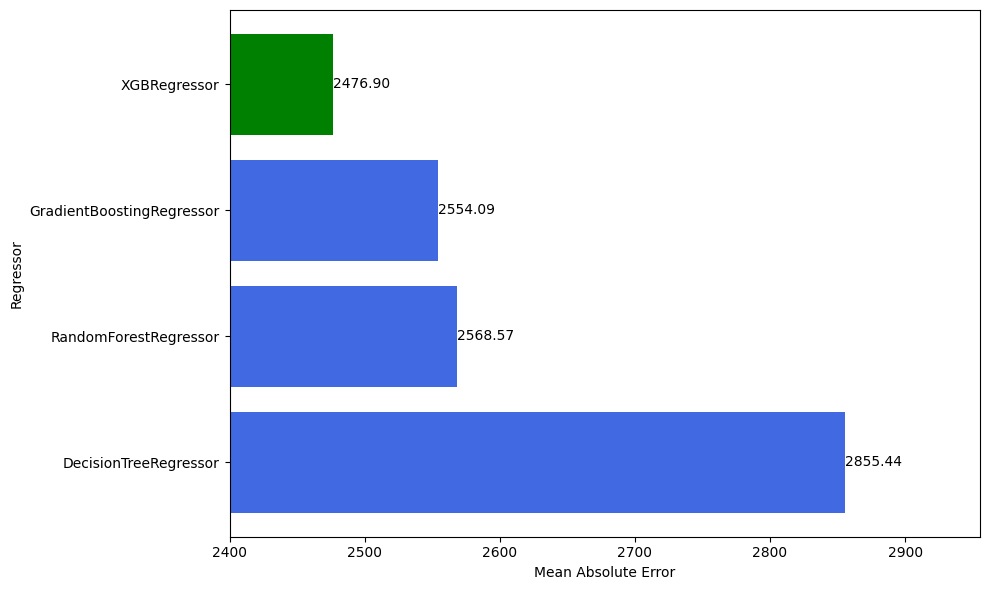

In [12]:
sorted_results = dict(sorted(grid_results.items(), key=lambda x: x[1]['mae'], reverse=True))

plt.figure(figsize=(10, 6))

colors = ['green' if name == best_model_name else 'royalblue' for name in sorted_results.keys()]

bars = plt.barh([name for name in sorted_results.keys()],[results['mae'] for results in sorted_results.values()],
                    color=colors)

plt.xlabel('Mean Absolute Error')
plt.ylabel('Regressor')
plt.xlim(2400, max(r['mae'] for r in sorted_results.values()) + 100) 

for bar, (name, results) in zip(bars, sorted_results.items()):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{results["mae"]:.2f}',
             va='center', ha='left', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# **Result**


In [13]:
print('='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)

print('\nBefore Hyperparameter Tuning:\n')
for name, score in zip([type(r).__name__ for r in regs], mae_scores):
    print(f'  {name:30s} MAE = {score:.2f}')

print('\nAfter Hyperparameter Tuning:\n')
for name, result in sorted(grid_results.items(), key=lambda x: x[1]['mae']):
    marker = ' ← BEST' if name == best_model_name else ''
    print(f'  {name:30s} MAE = {result["mae"]:.2f}{marker}')

print('\nImprovement from Tuning:\n')
for name, score in zip([type(r).__name__ for r in regs], mae_scores):
    if name in grid_results:
        before = score
        after  = grid_results[name]['mae']
        improvement = ((before - after) / before) * 100
        print(f'  {name:30s} {before:.2f} → {after:.2f}  ({improvement:.1f}% improvement)')

print(f'\nFinal Test Set Evaluation — {best_model_name}')

FINAL RESULTS SUMMARY

Before Hyperparameter Tuning:

  RandomForestRegressor          MAE = 2702.42
  DecisionTreeRegressor          MAE = 3162.45
  GradientBoostingRegressor      MAE = 2683.45
  XGBRegressor                   MAE = 3257.37

After Hyperparameter Tuning:

  XGBRegressor                   MAE = 2476.90 ← BEST
  GradientBoostingRegressor      MAE = 2554.09
  RandomForestRegressor          MAE = 2568.57
  DecisionTreeRegressor          MAE = 2855.44

Improvement from Tuning:

  RandomForestRegressor          2702.42 → 2568.57  (5.0% improvement)
  DecisionTreeRegressor          3162.45 → 2855.44  (9.7% improvement)
  GradientBoostingRegressor      2683.45 → 2554.09  (4.8% improvement)
  XGBRegressor                   3257.37 → 2476.90  (24.0% improvement)

Final Test Set Evaluation — XGBRegressor


# **Result Metrics**

## Without HyperParameter Tuning

##  **GradientBoost Regressor** 

In [20]:

insurancePipeline.set_params(reg = GradientBoostingRegressor(random_state = 42))
insurancePipeline.fit(X_train, y_train)

gb_test_pred = insurancePipeline.predict(X_test)
gb_train_pred = insurancePipeline.predict(X_train)


print("\n-------------------------------------------------------TRAINING SET----------------------------------------------    \n")

gb_train_r2score = metrics.r2_score(y_train, gb_train_pred)
gb_train_mae = metrics.mean_absolute_error(y_train, gb_train_pred)
gb_train_mse = metrics.mean_squared_error(y_train, gb_train_pred)
gb_train_rmse = np.sqrt(gb_train_mse)
gb_train_mape = metrics.mean_absolute_percentage_error(y_train ,gb_train_pred)

print(f"\t  R squared error : {gb_train_r2score:.5f}")
print(f'\t  Mean Absolute Error : {gb_train_mae:.5f}')
print(f'\t  Mean Absolute Percentage Error : {gb_train_mape:.5f}')
print(f"\t  Root Mean Square Error : {gb_train_rmse:.5f}")

print("\n-----------------------------------------------------------------------------------------------------------------    \n")


print("\n---------------------------------------------------------TEST SET------------------------------------------------    \n")

gb_test_r2score = metrics.r2_score(y_test, gb_test_pred)
gb_test_mae = metrics.mean_absolute_error(y_test, gb_test_pred)
gb_test_mse = metrics.mean_squared_error(y_test, gb_test_pred)
gb_test_rmse = np.sqrt(gb_test_mse)
gb_test_mape = metrics.mean_absolute_percentage_error(y_test, gb_test_pred)

print(f"\t  R squared error : {gb_test_r2score:.5f}")
print(f'\t  Mean Absolute Error : {gb_test_mae:.5f}')
print(f'\t  Mean Absolute Percentage Error : {gb_test_mape:.5f}')
print(f"\t  Root Mean Square Error : {gb_test_rmse:.5f}")

print("\n-----------------------------------------------------------------------------------------------------------------    \n")


-------------------------------------------------------TRAINING SET----------------------------------------------    

	  R squared error : 0.89592
	  Mean Absolute Error : 2143.71470
	  Mean Absolute Percentage Error : 0.26172
	  Root Mean Square Error : 3875.93856

-----------------------------------------------------------------------------------------------------------------    


---------------------------------------------------------TEST SET------------------------------------------------    

	  R squared error : 0.87774
	  Mean Absolute Error : 2442.23341
	  Mean Absolute Percentage Error : 0.29640
	  Root Mean Square Error : 4356.73560

-----------------------------------------------------------------------------------------------------------------    



## **RandomForest Regressor**

In [15]:
insurancePipeline.set_params(reg=RandomForestRegressor(random_state=42))
insurancePipeline.fit(X_train, y_train)

rf_test_pred = insurancePipeline.predict(X_test)
rf_train_pred = insurancePipeline.predict(X_train)


print("\n---------------------------------------------------TRAINING SET-------------------------------------------------    \n")

rf_train_r2score = metrics.r2_score(y_train , rf_train_pred)
rf_train_mae = metrics.mean_absolute_error(y_train, rf_train_pred)
rf_train_mse = metrics.mean_squared_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(rf_train_mse)
rf_train_mape = metrics.mean_absolute_percentage_error(y_train,rf_train_pred)

print("\t  R squared error for RF : ", f"{rf_train_r2score:.5f}")
print('\t  Mean Absolute Error for RF : ', f"{rf_train_mae:.5f}")
print('\t  Mean Absolute Percentage Error : ', f"{rf_train_mape:.5f}")
print("\t  Root Mean Square Error : ", f"{rf_train_rmse:.5f}")
print("\n-----------------------------------------------------------------------------------------------------------------   \n")

print("\n---------------------------------------------------TEST SET------------------------------------------------------    \n")

rf_test_r2score = metrics.r2_score(y_test, rf_test_pred)
rf_test_mae = metrics.mean_absolute_error(y_test, rf_test_pred)
rf_test_mse = metrics.mean_squared_error(y_test, rf_test_pred)
rf_test_rmse = np.sqrt(rf_test_mse)
rf_test_mape = metrics.mean_absolute_percentage_error(y_test, rf_test_pred)

print("\t  R squared error for RF : ", f"{rf_test_r2score:.5f}")
print('\t  Mean Absolute Error for RF : ', f"{rf_test_mae:.5f}")
print('\t  Mean Absolute Percentage Error : ', f"{rf_test_mape:.5f}")
print("\t  Root Mean Square Error : ", f"{rf_test_rmse:.5f}")

print("\n-------------------------------------------------------------------------------------------------------------------   \n")


---------------------------------------------------TRAINING SET-------------------------------------------------    

	  R squared error for RF :  0.94261
	  Mean Absolute Error for RF :  1393.82990
	  Mean Absolute Percentage Error :  0.15996
	  Root Mean Square Error :  2877.96143

-----------------------------------------------------------------------------------------------------------------   


---------------------------------------------------TEST SET------------------------------------------------------    

	  R squared error for RF :  0.86357
	  Mean Absolute Error for RF :  2438.71663
	  Mean Absolute Percentage Error :  0.29345
	  Root Mean Square Error :  4602.24433

-------------------------------------------------------------------------------------------------------------------   



## With HyperParameter Tuning

In [16]:
best_pipeline = grid_results[best_model_name]['best_estimator']

best_test_pred = best_pipeline.predict(X_test)
best_train_pred = best_pipeline.predict(X_train)

print(f"\n Best Model: { best_model_name}")
print("\n-------------------------------------------------------TRAINING SET----------------------------------------------    \n")

b_train_r2score = metrics.r2_score(y_train, best_train_pred)
b_train_mae = metrics.mean_absolute_error(y_train, best_train_pred)
b_train_mse = metrics.mean_squared_error(y_train, best_train_pred)
b_train_rmse = np.sqrt(b_train_mse)
b_train_mape = metrics.mean_absolute_percentage_error(y_train ,best_train_pred)

print("\t  R squared error : ", f"{b_train_r2score:.5f}")
print('\t  Mean Absolute Error : ', f"{b_train_mae:.5f}")
print('\t  Mean Absolute Percentage Error : ', f"{b_train_mape:.5f}")
print("\t  Root Mean Square Error : ", f"{b_train_rmse:.5f}")

print("\n-----------------------------------------------------------------------------------------------------------------    \n")


print("\n---------------------------------------------------------TEST SET------------------------------------------------    \n")

b_test_r2score = metrics.r2_score(y_test, best_test_pred)
b_test_mae = metrics.mean_absolute_error(y_test, best_test_pred)
b_test_mse = metrics.mean_squared_error(y_test, best_test_pred)
b_test_rmse = np.sqrt(b_test_mse)
b_test_mape = metrics.mean_absolute_percentage_error(y_test, best_test_pred)

print("\t  R squared error : ", f"{b_test_r2score:.5f}")
print('\t  Mean Absolute Error : ', f"{b_test_mae:.5f}")
print('\t  Mean Absolute Percentage Error : ', f"{b_test_mape:.5f}")
print("\t  Root Mean Square Error : ", f"{b_test_rmse:.5f}")

print("\n-----------------------------------------------------------------------------------------------------------------    \n")



 Best Model: XGBRegressor

-------------------------------------------------------TRAINING SET----------------------------------------------    

	  R squared error :  0.88466
	  Mean Absolute Error :  2284.31975
	  Mean Absolute Percentage Error :  0.27561
	  Root Mean Square Error :  4080.09341

-----------------------------------------------------------------------------------------------------------------    


---------------------------------------------------------TEST SET------------------------------------------------    

	  R squared error :  0.88105
	  Mean Absolute Error :  2463.91715
	  Mean Absolute Percentage Error :  0.31536
	  Root Mean Square Error :  4297.39085

-----------------------------------------------------------------------------------------------------------------    



# **Graphical Evaluation**

 ## 1. **Scatter Plot**

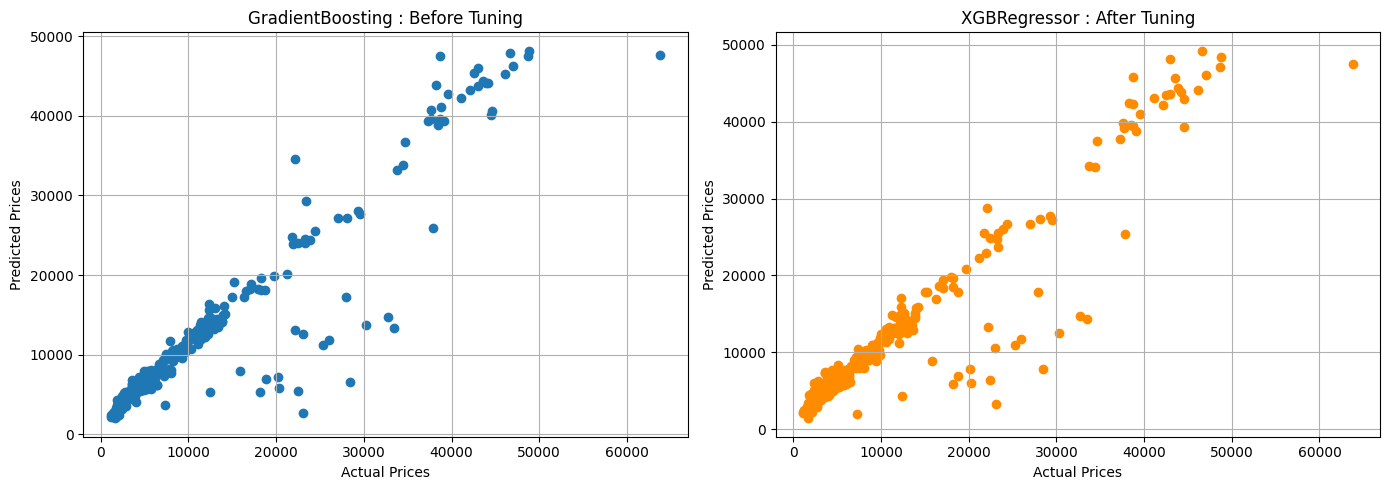

In [23]:
gb_residuals = y_test - gb_test_pred  
best_model_residuals = y_test - best_test_pred       

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax1.scatter(y_test, gb_test_pred)
ax1.set_xlabel("Actual Prices")
ax1.set_ylabel("Predicted Prices")
ax1.set_title("GradientBoosting : Before Tuning")
ax1.grid(True)

ax2.scatter(y_test, best_test_pred, color = 'darkorange')
ax2.set_xlabel("Actual Prices")
ax2.set_ylabel("Predicted Prices")
ax2.set_title(f"{best_model_name} : After Tuning")
ax2.grid(True)

plt.tight_layout()
plt.show()

## 2. **Residual Plot**

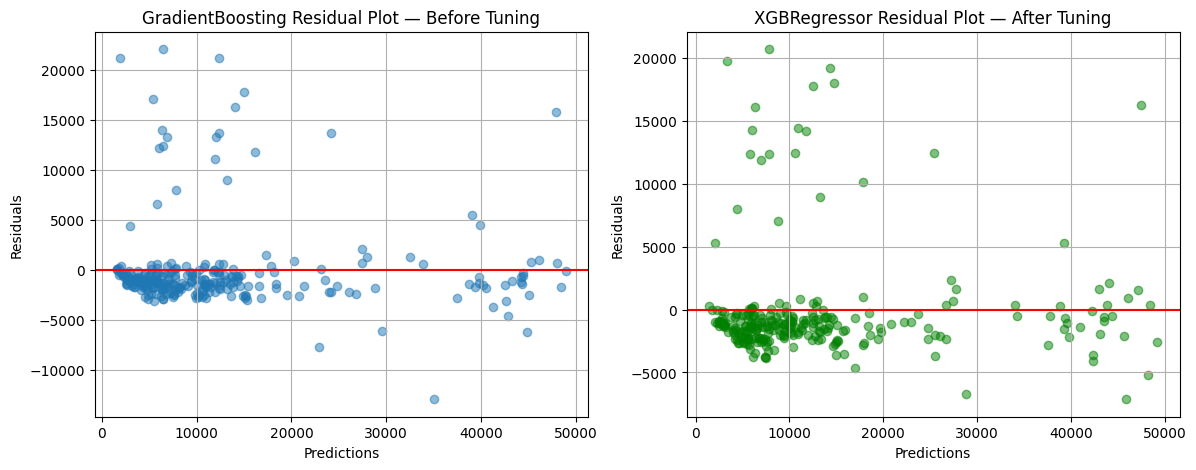

In [18]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

ax1.scatter(gb_test_pred, gb_residuals, alpha=0.5)
ax1.set_title('GradientBoosting Residual Plot — Before Tuning')
ax1.set_xlabel('Predictions')
ax1.set_ylabel('Residuals')
ax1.axhline(y=0, color='r', linestyle='-')
ax1.grid(True)

ax2.scatter(best_test_pred, best_model_residuals ,color = 'green', alpha=0.5)
ax2.set_title(f'{best_model_name} Residual Plot — After Tuning')
ax2.set_xlabel('Predictions')
ax2.set_ylabel('Residuals')
ax2.axhline(y=0, color='r', linestyle='-')
ax2.grid(True)

plt.show()

## 3. **Residual Histogram**

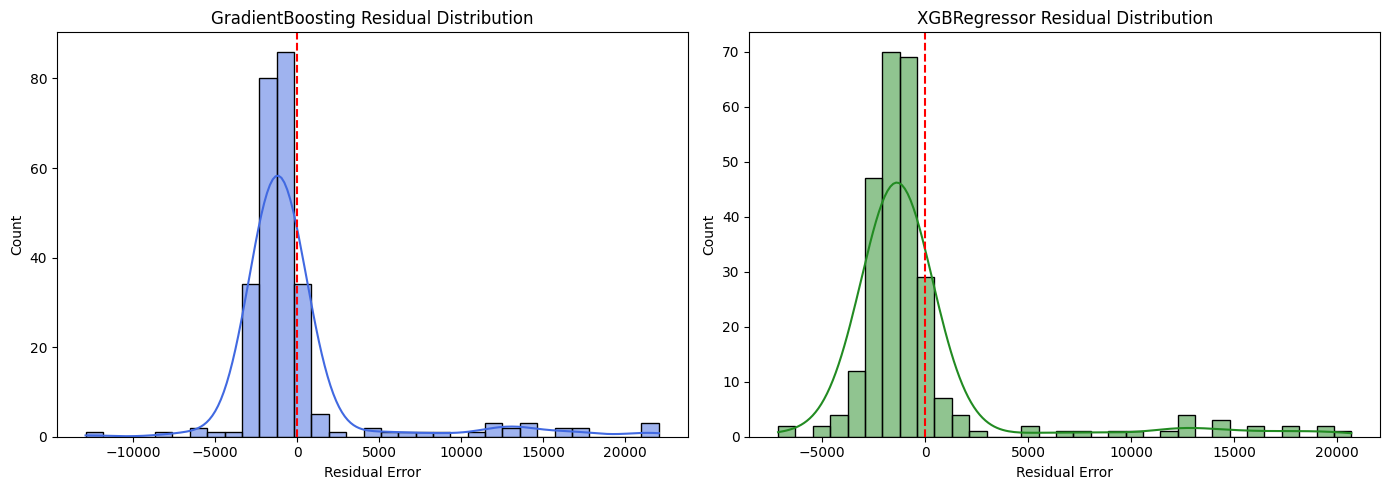

In [19]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.histplot(gb_residuals, kde=True, color='royalblue', ax = ax1) 
ax1.set_title('GradientBoosting Residual Distribution', fontsize = 12)
ax1.set_xlabel('Residual Error')
ax1.axvline(x = 0, color='red', linestyle='--', linewidth=1.5)

sns.histplot(best_model_residuals, kde=True, color='forestgreen', ax = ax2)
ax2.set_title(f'{best_model_name} Residual Distribution', fontsize=12)
ax2.set_xlabel('Residual Error')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5) 

plt.tight_layout()
plt.show()


## Residual Analysis — After Feature Engineering

Adding smoker_bmi and smoker_age interaction features 
significantly improved residual distribution , peak shifted 
closer to 0 and distribution is more symmetric.

Remaining right tail corresponds to extreme high-charge cases 
(heavy smokers with high BMI) which are underrepresented in 
the dataset which is a data limitation rather than a model failure.